## AI Manufacturing Shortage & Production Risk Agent

This project demonstrates an AI-assisted manufacturing decision-support prototype designed to identify potential material shortages and production risks.

The prototype uses **Python, Pandas, and Jupyter Notebook** to analyze manufacturing and supply-chain data, including:

- Required production quantities
- Current inventory
- Open purchase orders
- Supplier lead times
- Material shortages
- Production risk
- Shortage cost exposure

The system identifies components that may create production risk and provides recommended actions for review by manufacturing and supply-chain professionals.

### Machine Learning Expansion

The next phase of this project explores **machine learning to predict supplier lead time**.

Instead of relying only on a fixed supplier lead time, a supervised regression model could analyze historical purchase orders, supplier performance, order quantities, transportation information, weather, and other disruptions to predict the actual number of days required for a component to arrive.

The predicted lead time could then become an input to the Manufacturing Shortage & Production Risk Agent.

**Workflow:**

Purchase Order → ML Lead-Time Prediction → Inventory Analysis → Shortage Risk → Recommended Action → Human Decision

### Responsible AI Considerations

The project maintains a **human-in-the-loop approach**. Machine learning predictions should support rather than replace purchasing and production decisions.

Important considerations include:

- Supplier and purchasing data privacy
- Protection of confidential pricing and contract information
- Data quality and accuracy
- Potential bias against suppliers based on historical performance
- Model transparency and explainability
- Human review of significant risk predictions

### Project Notebook

[Open AI Manufacturing Shortage Agent Notebook](http://localhost:8888/notebooks/AI_Manufacturing_Shortage_Agent.ipynb)

%pip install pandas

import pandas as pd

#AI Manufacturing Shortage & Production Risk Agen
data = {
    "Part_Number": ["P-101", "P-102", "P-103", "P-104"],
    "Description": [
        "Heating Element",
        "Temperature Sensor",
        "Control Module",
        "Wiring Harness"
    ],
    "Required_Qty": [500, 500, 500, 500],
    "Inventory_Qty": [320, 475, 200, 550],
    "Open_PO_Qty": [100, 100, 150, 0],
    "Lead_Time_Days": [21, 7, 30, 14],
    "Unit_Cost": [42, 18, 85, 26]
}

# Convert the data into a table
df = pd.DataFrame(data)

# Display the table
df

## Machine Learning Expansion: Supplier Lead-Time Prediction

### Domain: Supply Chain and Manufacturing

This project explores how machine learning can improve manufacturing and supply-chain decision-making by predicting the **actual lead time of purchase orders**.

Manufacturers depend on suppliers to deliver materials and components according to production schedules. Traditional planning may rely on fixed supplier lead times, but actual delivery times can change because of weather, material availability, transportation delays, labor disruptions, supplier performance, and other factors.

### Machine Learning Problem

**Can historical purchasing, supplier, material, transportation, and external-event data be used to predict the number of days required for a purchase order to be delivered?**

The predicted lead time could be incorporated into the **AI Manufacturing Shortage & Production Risk Agent** to identify potential shortages earlier.

### Type of Machine Learning

This is a **Supervised Learning – Regression** problem.

- **Supervised Learning:** Historical purchase orders contain known actual delivery times that can be used to train the model.
- **Regression:** The model predicts a numerical value — the expected number of days required for delivery.

### Data Needed

Potential model features include:

- Historical purchase-order data
- Supplier delivery history
- Order quantity
- Part or material type
- Current inventory
- Supplier location
- Transportation method
- Historical lead times
- Weather conditions
- Labor or transportation disruptions
- Seasonal and holiday effects
- Required production date

### Proposed Workflow

**Purchase Order → ML Lead-Time Prediction → Inventory Analysis → Production Risk → Recommended Action → Human Decision**

### Ethical and Privacy Considerations

Supplier names, pricing, purchase-order history, contract information, and production schedules may contain confidential business information and should be appropriately protected.

Historical data could also introduce bias. For example, a supplier that experienced temporary delays because of weather or transportation problems could continue receiving higher predicted lead times after conditions improve.

The model should therefore remain a **decision-support tool with human oversight**, rather than automatically making supplier, purchasing, or sourcing decisions.

In [2]:
import pandas as pd

In [3]:
data = {
    "Part_Number": ["P-101", "P-102", "P-103", "P-104"],
    "Description": ["Heating Element", "Temperature Sensor", "Control Module", "Wiring Harness"],
    "Required_Qty": [500, 500, 500, 500],
    "Inventory_Qty": [320, 475, 200, 550],
    "Open_PO_Qty": [100, 100, 150, 0],
    "Lead_Time_Days": [21, 7, 30, 14],
    "Unit_Cost": [42, 18, 85, 26]
}

df = pd.DataFrame(data)
df

,Part_Number,Description,Required_Qty,Inventory_Qty,Open_PO_Qty,Lead_Time_Days,Unit_Cost
0,P-101,Heating Element,500,320,100,21,42
1,P-102,Temperature Sensor,500,475,100,7,18
2,P-103,Control Module,500,200,150,30,85
3,P-104,Wiring Harness,500,550,0,14,26


In [4]:
# Calculate total material available
df["Net_Available"] = df["Inventory_Qty"] + df["Open_PO_Qty"]

# Calculate shortage quantity
df["Shortage_Qty"] = df["Required_Qty"] - df["Net_Available"]

# Prevent negative numbers when we have enough inventory
df["Shortage_Qty"] = df["Shortage_Qty"].clip(lower=0)

# Display the updated table
df

,Part_Number,Description,Required_Qty,Inventory_Qty,Open_PO_Qty,Lead_Time_Days,Unit_Cost,Net_Available,Shortage_Qty
0,P-101,Heating Element,500,320,100,21,42,420,80
1,P-102,Temperature Sensor,500,475,100,7,18,575,0
2,P-103,Control Module,500,200,150,30,85,350,150
3,P-104,Wiring Harness,500,550,0,14,26,550,0


In [5]:
# Create a function to determine production shortage risk
def calculate_risk(row):
    if row["Shortage_Qty"] == 0:
        return "OK"
    elif row["Shortage_Qty"] >= 100 and row["Lead_Time_Days"] >= 21:
        return "HIGH"
    elif row["Shortage_Qty"] > 0 and row["Lead_Time_Days"] >= 14:
        return "MEDIUM"
    else:
        return "LOW"

# Apply the risk logic to every part
df["Risk_Level"] = df.apply(calculate_risk, axis=1)

# Display the results
df[[
    "Part_Number",
    "Description",
    "Shortage_Qty",
    "Lead_Time_Days",
    "Risk_Level"
]]

,Part_Number,Description,Shortage_Qty,Lead_Time_Days,Risk_Level
0,P-101,Heating Element,80,21,MEDIUM
1,P-102,Temperature Sensor,0,7,OK
2,P-103,Control Module,150,30,HIGH
3,P-104,Wiring Harness,0,14,OK


In [6]:
# Create purchasing recommendations
def recommend_action(row):
    if row["Risk_Level"] == "HIGH":
        return (
            f"URGENT: {row['Part_Number']} {row['Description']} has a "
            f"{row['Shortage_Qty']}-unit shortage with a "
            f"{row['Lead_Time_Days']}-day supplier lead time. "
            "Recommend expediting the existing purchase order "
            "or evaluating an alternate supplier."
        )

    elif row["Risk_Level"] == "MEDIUM":
        return (
            f"WARNING: {row['Part_Number']} {row['Description']} has a "
            f"{row['Shortage_Qty']}-unit shortage. "
            "Review the open purchase order and confirm the supplier "
            "delivery date."
        )

    elif row["Risk_Level"] == "LOW":
        return (
            f"MONITOR: {row['Part_Number']} {row['Description']} has a "
            "small shortage. Continue monitoring inventory and demand."
        )

    else:
        return (
            f"OK: {row['Part_Number']} {row['Description']} has sufficient "
            "material available for current production demand."
        )

# Apply recommendation logic
df["Agent_Recommendation"] = df.apply(recommend_action, axis=1)

# Display recommendations
for recommendation in df["Agent_Recommendation"]:
    print(recommendation)
    print()


OK: P-102 Temperature Sensor has sufficient material available for current production demand.

URGENT: P-103 Control Module has a 150-unit shortage with a 30-day supplier lead time. Recommend expediting the existing purchase order or evaluating an alternate supplier.

OK: P-104 Wiring Harness has sufficient material available for current production demand.



In [7]:
# TEST SCENARIO:
# Supplier adds 200 units to the P-103 open purchase order

df.loc[df["Part_Number"] == "P-103", "Open_PO_Qty"] = 350

# Recalculate available inventory
df["Net_Available"] = df["Inventory_Qty"] + df["Open_PO_Qty"]

# Recalculate shortage
df["Shortage_Qty"] = (
    df["Required_Qty"] - df["Net_Available"]
).clip(lower=0)

# Recalculate risk
df["Risk_Level"] = df.apply(calculate_risk, axis=1)

# Generate new recommendations
df["Agent_Recommendation"] = df.apply(recommend_action, axis=1)

# Show P-103 test result
df.loc[
    df["Part_Number"] == "P-103",
    [
        "Part_Number",
        "Description",
        "Open_PO_Qty",
        "Net_Available",
        "Shortage_Qty",
        "Risk_Level",
        "Agent_Recommendation"
    ]
]

,Part_Number,Description,Open_PO_Qty,Net_Available,Shortage_Qty,Risk_Level,Agent_Recommendation
2,P-103,Control Module,350,550,0,OK,OK: P-103 Control Module has sufficient materi...


In [8]:
# Restore P-103 to the original test condition
df.loc[df["Part_Number"] == "P-103", "Open_PO_Qty"] = 150

# Add number of days until the part is needed for production
df["Days_Until_Production"] = [14, 20, 12, 30]

# Recalculate inventory position
df["Net_Available"] = df["Inventory_Qty"] + df["Open_PO_Qty"]

df["Shortage_Qty"] = (
    df["Required_Qty"] - df["Net_Available"]
).clip(lower=0)

# Calculate whether supplier lead time exceeds production window
df["Days_Late"] = (
    df["Lead_Time_Days"] - df["Days_Until_Production"]
).clip(lower=0)

# Display production timing risk
df[[
    "Part_Number",
    "Description",
    "Shortage_Qty",
    "Lead_Time_Days",
    "Days_Until_Production",
    "Days_Late"
]]

,Part_Number,Description,Shortage_Qty,Lead_Time_Days,Days_Until_Production,Days_Late
0,P-101,Heating Element,80,21,14,7
1,P-102,Temperature Sensor,0,7,20,0
2,P-103,Control Module,150,30,12,18
3,P-104,Wiring Harness,0,14,30,0


In [9]:
# Enhanced risk assessment using shortage AND production timing
def calculate_production_risk(row):

    if row["Shortage_Qty"] == 0:
        return "OK"

    elif row["Days_Late"] >= 14:
        return "CRITICAL"

    elif row["Days_Late"] >= 7:
        return "HIGH"

    elif row["Days_Late"] > 0:
        return "MEDIUM"

    else:
        return "LOW"


# Apply enhanced production risk logic
df["Production_Risk"] = df.apply(
    calculate_production_risk,
    axis=1
)

# Display results
df[[
    "Part_Number",
    "Description",
    "Shortage_Qty",
    "Lead_Time_Days",
    "Days_Until_Production",
    "Days_Late",
    "Production_Risk"
]]

,Part_Number,Description,Shortage_Qty,Lead_Time_Days,Days_Until_Production,Days_Late,Production_Risk
0,P-101,Heating Element,80,21,14,7,HIGH
1,P-102,Temperature Sensor,0,7,20,0,OK
2,P-103,Control Module,150,30,12,18,CRITICAL
3,P-104,Wiring Harness,0,14,30,0,OK


In [10]:
# Generate production-risk recommendations
def production_recommendation(row):

    if row["Production_Risk"] == "CRITICAL":
        return (
            f"CRITICAL: {row['Part_Number']} {row['Description']} is "
            f"{row['Shortage_Qty']} units short. Production requires the "
            f"component in {row['Days_Until_Production']} days, but supplier "
            f"lead time is {row['Lead_Time_Days']} days, creating a "
            f"{row['Days_Late']}-day timing gap. "
            "Recommend immediately evaluating PO expediting, alternate "
            "suppliers, or production schedule adjustments."
        )

    elif row["Production_Risk"] == "HIGH":
        return (
            f"HIGH: {row['Part_Number']} {row['Description']} is "
            f"{row['Shortage_Qty']} units short with a "
            f"{row['Days_Late']}-day timing gap. "
            "Recommend contacting the supplier to confirm delivery and "
            "evaluate expedited shipping."
        )

    elif row["Production_Risk"] == "MEDIUM":
        return (
            f"MEDIUM: {row['Part_Number']} {row['Description']} has a "
            "potential production timing risk. Monitor supplier delivery "
            "and inventory status."
        )

    elif row["Production_Risk"] == "LOW":
        return (
            f"LOW: {row['Part_Number']} {row['Description']} has a shortage, "
            "but current supplier timing can support the production window."
        )

    else:
        return (
            f"OK: {row['Part_Number']} {row['Description']} currently has "
            "sufficient material for production."
        )


# Apply recommendation engine
df["Production_Recommendation"] = df.apply(
    production_recommendation,
    axis=1
)

# Print the agent's recommendations
for recommendation in df["Production_Recommendation"]:
    print(recommendation)
    print()

HIGH: P-101 Heating Element is 80 units short with a 7-day timing gap. Recommend contacting the supplier to confirm delivery and evaluate expedited shipping.

OK: P-102 Temperature Sensor currently has sufficient material for production.

CRITICAL: P-103 Control Module is 150 units short. Production requires the component in 12 days, but supplier lead time is 30 days, creating a 18-day timing gap. Recommend immediately evaluating PO expediting, alternate suppliers, or production schedule adjustments.

OK: P-104 Wiring Harness currently has sufficient material for production.



# AI Manufacturing Shortage & Production Risk Agent

### AI-Assisted Manufacturing Decision-Support Prototype

**Version 1.0**

## Project Overview

This project demonstrates an AI-assisted, rule-based manufacturing decision-support prototype developed using Python, Pandas, Jupyter Notebook, and AI-assisted vibe coding.

The prototype analyzes manufacturing inventory, open purchase orders, production requirements, supplier lead times, and production timing to identify potential component shortages before they disrupt production.

## Business Objective

Provide production planners and purchasing professionals with earlier visibility into material shortages and supplier timing risks so they can evaluate corrective actions before production is affected.

## Decision Workflow

**Production Demand → Inventory → Open Purchase Orders → Shortage Detection → Supplier Lead Time → Production Timing → Risk Classification → Recommended Action → Human Review**

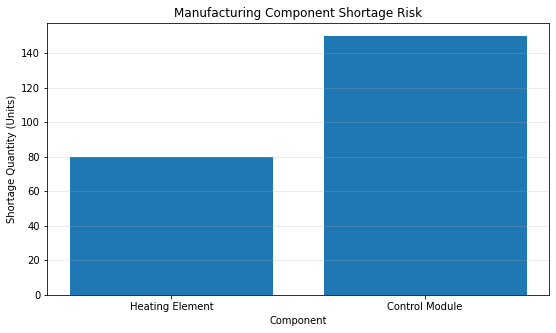

In [11]:
import matplotlib.pyplot as plt

# Create a simple shortage risk chart
risk_data = df[df["Shortage_Qty"] > 0].copy()

plt.figure(figsize=(9, 5))

plt.bar(
    risk_data["Description"],
    risk_data["Shortage_Qty"]
)

plt.title("Manufacturing Component Shortage Risk")
plt.xlabel("Component")
plt.ylabel("Shortage Quantity (Units)")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [12]:
import matplotlib.pyplot as plt

In [13]:
import matplotlib.pyplot as plt

# Create a simple shortage risk chart
risk_data = df[df["Shortage_Qty"] > 0].copy()

In [ ]:
import pandas as pd

# Sample manufacturing inventory data
data = {
    "Part_Number": ["P-101", "P-102", "P-103", "P-104"],
    "Description": [
        "Heating Element",
        "Temperature Sensor",
        "Control Module",
        "Wiring Harness"
    ],
    "Required_Qty": [500, 500, 500, 500],
    "Inventory_Qty": [320, 475, 200, 550],
    "Open_PO_Qty": [100, 100, 150, 0],
    "Lead_Time_Days": [21, 7, 30, 14],
    "Unit_Cost": [42, 18, 85, 26]
}

# Create dataframe
df = pd.DataFrame(data)

# Calculate available material
df["Net_Available"] = df["Inventory_Qty"] + df["Open_PO_Qty"]

# Calculate shortage
df["Shortage_Qty"] = (
    df["Required_Qty"] - df["Net_Available"]
).clip(lower=0)

df

In [ ]:
import matplotlib.pyplot as plt

# Select only components with shortages
risk_data = df[df["Shortage_Qty"] > 0].copy()

# Create shortage chart
plt.figure(figsize=(9, 5))

plt.bar(
    risk_data["Description"],
    risk_data["Shortage_Qty"]
)

plt.title("Manufacturing Component Shortage Risk")
plt.xlabel("Component")
plt.ylabel("Shortage Quantity (Units)")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
# Add production timing information
df["Days_Until_Production"] = [14, 20, 12, 30]

# Calculate supplier timing gap
df["Days_Late"] = (
    df["Lead_Time_Days"] - df["Days_Until_Production"]
).clip(lower=0)

# Classify production risk
def classify_risk(row):
    if row["Shortage_Qty"] == 0:
        return "OK"
    elif row["Days_Late"] >= 14:
        return "CRITICAL"
    elif row["Days_Late"] >= 7:
        return "HIGH"
    elif row["Days_Late"] > 0:
        return "MEDIUM"
    else:
        return "LOW"

df["Production_Risk"] = df.apply(classify_risk, axis=1)

# Display management risk summary
df[[
    "Part_Number",
    "Description",
    "Shortage_Qty",
    "Lead_Time_Days",
    "Days_Until_Production",
    "Days_Late",
    "Production_Risk"
]]

In [ ]:
# Executive Alert and Recommendation Engine

def executive_alert(row):

    if row["Production_Risk"] == "CRITICAL":
        return (
            f"IMMEDIATE ACTION: {row['Part_Number']} {row['Description']} "
            f"is {row['Shortage_Qty']} units short with "
            f"${row['Shortage_Cost_Exposure']:,.0f} in component exposure. "
            f"Supplier timing exceeds the production requirement by "
            f"{row['Days_Late']} days. "
            f"Evaluate PO expediting, alternate suppliers, "
            f"or production schedule adjustment."
        )

    elif row["Production_Risk"] == "HIGH":
        return (
            f"HIGH PRIORITY: {row['Part_Number']} {row['Description']} "
            f"is {row['Shortage_Qty']} units short with "
            f"${row['Shortage_Cost_Exposure']:,.0f} in component exposure. "
            f"Supplier timing gap is {row['Days_Late']} days. "
            f"Contact supplier and evaluate expedited delivery."
        )

    elif row["Production_Risk"] == "MEDIUM":
        return (
            f"MONITOR: {row['Part_Number']} {row['Description']} "
            f"has a potential production timing risk. "
            f"Confirm supplier delivery status."
        )

    elif row["Production_Risk"] == "LOW":
        return (
            f"MONITOR: {row['Part_Number']} {row['Description']} "
            f"has a material shortage, but current supplier timing "
            f"supports the production window."
        )

    else:
        return (
            f"OK: {row['Part_Number']} {row['Description']} "
            f"currently has sufficient material for production."
        )


# Apply the agent
df["Executive_Alert"] = df.apply(executive_alert, axis=1)

# Print executive alerts
for alert in df["Executive_Alert"]:
    print(alert)
    print()

In [ ]:
# Calculate financial exposure from component shortages
df["Shortage_Cost_Exposure"] = (
    df["Shortage_Qty"] * df["Unit_Cost"]
)

# Display financial risk summary
df[[
    "Part_Number",
    "Description",
    "Shortage_Qty",
    "Unit_Cost",
    "Shortage_Cost_Exposure",
    "Production_Risk"
]]

In [ ]:
%pip install pandas

In [ ]:
# Calculate total material available
df["Net_Available"] = df["Inventory_Qty"] + df["Open_PO_Qty"]

# Calculate shortage quantity
df["Shortage_Qty"] = df["Required_Qty"] - df["Net_Available"]

# Prevent negative shortages
df["Shortage_Qty"] = df["Shortage_Qty"].clip(lower=0)

# Display updated table
df

In [ ]:
def classify_risk(row):
    if row["Shortage_Qty"] == 0:
        return "OK"
    elif row["Shortage_Qty"] >= 100 and row["Lead_Time_Days"] >= 21:
        return "CRITICAL"
    elif row["Shortage_Qty"] >= 50:
        return "HIGH"
    else:
        return "MEDIUM"

df["Production_Risk"] = df.apply(classify_risk, axis=1)

df[["Part_Number", "Description", "Shortage_Qty",
    "Lead_Time_Days", "Production_Risk"]]

In [ ]:
# Calculate financial exposure from each shortage
df["Shortage_Cost_Exposure"] = df["Shortage_Qty"] * df["Unit_Cost"]

# Display financial risk
df[["Part_Number", "Description", "Shortage_Qty",
    "Unit_Cost", "Shortage_Cost_Exposure",
    "Production_Risk"]]

In [ ]:
def recommend_action(row):
    if row["Production_Risk"] == "CRITICAL":
        return "Escalate immediately; contact supplier and evaluate alternate sourcing."
    elif row["Production_Risk"] == "HIGH":
        return "Expedite purchase order and confirm supplier delivery date."
    elif row["Production_Risk"] == "MEDIUM":
        return "Monitor inventory and supplier lead time."
    else:
        return "No immediate action required."

df["Recommended_Action"] = df.apply(recommend_action, axis=1)

df[["Part_Number", "Description", "Production_Risk",
    "Shortage_Cost_Exposure", "Recommended_Action"]]

In [ ]:
# Create management alert dashboard
alerts = df[df["Production_Risk"].isin(["HIGH", "CRITICAL"])][
    ["Part_Number", "Description", "Shortage_Qty",
     "Lead_Time_Days", "Shortage_Cost_Exposure",
     "Production_Risk", "Recommended_Action"]
]

print("AI MANUFACTURING RISK ALERT")
print("---------------------------")
print(f"Components requiring attention: {len(alerts)}")
print(f"Total shortage cost exposure: ${alerts['Shortage_Cost_Exposure'].sum():,.2f}")

alerts

In [1]:
import os
print(os.getcwd())

C:\Users\Valued Customer


# Machine Learning Regression Model: Supplier Lead-Time Prediction

## Objective

The purpose of this machine learning model is to predict the **actual lead time of a purchase order** using historical supply-chain data.

Instead of relying only on a fixed supplier lead time, the model will learn from historical purchasing and supplier information to estimate how many days a future purchase order may take to arrive.

The predicted lead time can eventually be incorporated into the **AI Manufacturing Shortage & Production Risk Agent** to improve shortage and production-risk predictions.

## Machine Learning Approach

This is a **Supervised Learning – Regression** problem.

- **Inputs (Features):** Information about the purchase order and supplier
- **Target:** Actual Lead Time in days
- **Model:** Linear Regression
- **Goal:** Predict the number of days required for a purchase order to be delivered

### Step 2 — Create the Historical Purchase-Order Dataset

This step creates a small **synthetic historical purchase-order dataset** that will be used to train and test the Linear Regression model.

The dataset contains **20 sample purchase orders** and four variables:

- **Order Quantity** — the number of units included in the purchase order
- **Supplier Historical Lead Time** — the supplier's previous delivery performance in days
- **Transportation Days** — the estimated time required to transport the material
- **Actual Lead Time Days** — the actual number of days required for the purchase order to arrive

The first three variables will eventually be used as **input features**, while **Actual Lead Time Days** will be the value the machine-learning model learns to predict.

The dataset used in this prototype is **synthetic and created for educational purposes**. It does not contain confidential supplier or company purchasing information.

In a real manufacturing environment, this data could come from historical purchase orders, supplier-performance records, ERP systems, transportation systems, and other supply-chain data sources.

In [13]:
import pandas as pd

# Historical purchase-order training data
lead_time_data = {
    "Order_Quantity": [100, 150, 200, 250, 300, 350, 400, 450, 500, 550,
                       600, 650, 700, 750, 800, 850, 900, 950, 1000, 1100],
    
    "Supplier_History_Days": [10, 12, 14, 15, 16, 18, 17, 20, 21, 22,
                              24, 23, 25, 27, 26, 29, 30, 31, 33, 35],
    
    "Transportation_Days": [2, 3, 2, 4, 3, 5, 4, 5, 6, 5,
                            7, 6, 7, 8, 7, 9, 8, 10, 9, 11],
    
    "Actual_Lead_Time_Days": [12, 15, 16, 19, 19, 23, 22, 25, 28, 28,
                              31, 30, 33, 36, 35, 39, 39, 42, 43, 47]
}

lead_time_df = pd.DataFrame(lead_time_data)

lead_time_df

,Order_Quantity,Supplier_History_Days,Transportation_Days,Actual_Lead_Time_Days
0,100,10,2,12
1,150,12,3,15
2,200,14,2,16
3,250,15,4,19
4,300,16,3,19
5,350,18,5,23
6,400,17,4,22
7,450,20,5,25
8,500,21,6,28
9,550,22,5,28


### Step 3 — Separate the Input Features and Target Variable

This step separates the dataset into the information the model will use to make predictions and the value the model is trying to predict.

The **input features (X)** are:

- **Order Quantity** — number of units ordered
- **Supplier Historical Lead Time** — the supplier's previous delivery performance
- **Transportation Days** — estimated transportation time

The **target variable (y)** is:

- **Actual Lead Time in Days** — the actual number of days required for the purchase order to arrive

In supervised machine learning, the model learns the relationship between the input features (**X**) and the known target (**y**).

The goal is for the model to eventually use new purchase-order information to predict an **Actual Lead Time** that is not yet known.

In [2]:
# Select the input features
X = lead_time_df[
    ["Order_Quantity", "Supplier_History_Days", "Transportation_Days"]
]

# Select the target we want to predict
y = lead_time_df["Actual_Lead_Time_Days"]

print("Input Features (X):")
display(X.head())

print("Target (y):")
display(y.head())

Input Features (X):


,Order_Quantity,Supplier_History_Days,Transportation_Days
0,100,10,2
1,150,12,3
2,200,14,2
3,250,15,4
4,300,16,3


Target (y):


0    12
1    15
2    16
3    19
4    19
Name: Actual_Lead_Time_Days, dtype: int64

### Step 4 — Split the Data into Training and Testing Sets

This step divides the historical purchase-order dataset into **training data** and **testing data**.

The dataset contains **20 sample purchase orders** and is divided as follows:

- **80% Training Data:** 16 purchase orders
- **20% Testing Data:** 4 purchase orders

The **training data** is used to teach the Linear Regression model the relationship between the input features and actual supplier lead time.

The **testing data** is kept separate from the training process. After the model is trained, these records are used to evaluate how well the model predicts lead times for purchase orders it did not see during training.

A `random_state` value is used so that the same training and testing records are selected each time the notebook is run.

This separation helps determine whether the model has learned a useful relationship rather than simply memorizing the training data.

In [3]:
from sklearn.model_selection import train_test_split

# Split the data: 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 16
Testing records: 4


### Step 5 — Train the Linear Regression Model

This step creates and trains the **Linear Regression model** using the historical purchase-order training data.

The model learns the relationship between the input features:

- **Order Quantity**
- **Supplier Historical Lead Time**
- **Transportation Time**

and the target:

- **Actual Lead Time in Days**

The `fit()` function trains the model using the 16 purchase orders contained in the training dataset.

During training, the model looks for mathematical relationships between the input features and actual supplier lead time. Once trained, the model can use those learned relationships to estimate lead times for purchase orders it has not previously seen.

The next step will test the trained model by asking it to make predictions using the test dataset.

In [4]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
lead_time_model = LinearRegression()

# Train the model using the training data
lead_time_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [5]:
lead_time_model.fit(X_train, y_train)

LinearRegression()

### Step 6 — Make Predictions on the Test Data

This step uses the trained Linear Regression model to predict supplier lead times for the purchase orders in the **test dataset**.

The model receives three input features:

- **Order Quantity**
- **Supplier Historical Lead Time**
- **Transportation Time**

The predicted lead times are then compared with the **actual lead times** to see how closely the model's predictions match the known results.

The comparison table displays:

- Purchase order input information
- Actual supplier lead time
- Predicted supplier lead time

For this prototype, the predicted values are close to the actual values in the small synthetic test dataset. The next step evaluates these predictions using formal model-performance metrics.

In [6]:
# Predict lead times for the test purchase orders
y_pred = lead_time_model.predict(X_test)

# Compare actual lead times with predicted lead times
results = X_test.copy()
results["Actual_Lead_Time"] = y_test
results["Predicted_Lead_Time"] = y_pred.round(2)

results

,Order_Quantity,Supplier_History_Days,Transportation_Days,Actual_Lead_Time,Predicted_Lead_Time
0,100,10,2,12,12.61
17,950,31,10,42,42.28
15,850,29,9,39,38.99
1,150,12,3,15,15.30


### Step 7 — Evaluate the Regression Model

This step evaluates how closely the Linear Regression model's predictions match the actual supplier lead times in the test data.

Three performance metrics are used:

- **Mean Absolute Error (MAE):** Measures the average difference between the actual and predicted lead times.
- **Root Mean Squared Error (RMSE):** Measures prediction error while giving greater weight to larger errors.
- **R-squared (R²):** Measures how well the model explains the variation in the target variable.

For this prototype, the model produced:

- **MAE:** 0.30 days
- **RMSE:** 0.37 days
- **R²:** 0.999

These results show a very close fit for the small synthetic dataset used in this demonstration. Because the dataset contains only 20 sample records and was created for learning purposes, these results should be treated as **proof-of-concept performance rather than evidence of real-world predictive accuracy**.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate model performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("-----------------")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")
print(f"R-squared (R²): {r2:.3f}")

MODEL PERFORMANCE
-----------------
Mean Absolute Error (MAE): 0.30 days
Root Mean Squared Error (RMSE): 0.37 days
R-squared (R²): 0.999


### Step 8 — Visualize Actual vs. Predicted Lead Time

This step visually compares the **actual supplier lead times** with the **lead times predicted by the Linear Regression model**.

The graph plots:

- **Actual Lead Time** on the X-axis
- **Predicted Lead Time** on the Y-axis
- A diagonal reference line representing a perfect prediction

Points that fall close to the diagonal line indicate that the model's predictions are close to the actual values.

For this small synthetic test dataset, the predicted values are very close to the actual lead times. These results demonstrate the regression workflow as a **proof of concept** and should not be interpreted as real-world model performance.

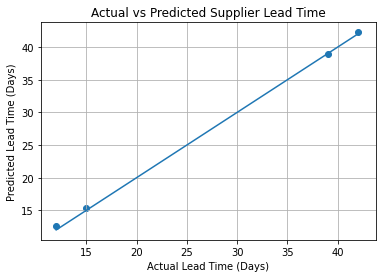

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

# Reference line: perfect prediction
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum])

plt.xlabel("Actual Lead Time (Days)")
plt.ylabel("Predicted Lead Time (Days)")
plt.title("Actual vs Predicted Supplier Lead Time")
plt.grid(True)

plt.show()

### Step 9 — Predict a New Purchase Order

This step uses the trained Linear Regression model to estimate the **actual supplier lead time for a new purchase order**.

The new order contains three input features:

- **Order Quantity:** 725 units
- **Supplier Historical Lead Time:** 26 days
- **Transportation Time:** 8 days

The trained model uses these inputs to predict how many days the purchase order may take to arrive. This predicted lead time can then be passed to the production-risk analysis to determine whether the component is expected to arrive before it is needed.

In [14]:
# Create a new purchase order for prediction
new_order = pd.DataFrame({
    "Order_Quantity": [725],
    "Supplier_History_Days": [26],
    "Transportation_Days": [8]
})

# Predict the supplier lead time
predicted_days = lead_time_model.predict(new_order)[0]

print("NEW PURCHASE ORDER PREDICTION")
print("-----------------------------")
print(f"Order Quantity: {new_order['Order_Quantity'][0]}")
print(f"Supplier Historical Lead Time: {new_order['Supplier_History_Days'][0]} days")
print(f"Transportation Time: {new_order['Transportation_Days'][0]} days")
print(f"Predicted Actual Lead Time: {predicted_days:.2f} days")

NEW PURCHASE ORDER PREDICTION
-----------------------------
Order Quantity: 725
Supplier Historical Lead Time: 26 days
Transportation Time: 8 days
Predicted Actual Lead Time: 34.85 days


### Step 10 — Turn the Prediction into a Manufacturing Decision

In [10]:
# Compare predicted lead time with production need date
days_until_needed = 30

if predicted_days > days_until_needed:
    delay_days = predicted_days - days_until_needed
    print("PRODUCTION RISK ALERT")
    print("---------------------")
    print(f"Predicted Lead Time: {predicted_days:.2f} days")
    print(f"Component Needed In: {days_until_needed} days")
    print(f"Potential Delay: {delay_days:.2f} days")
    print("Risk Status: HIGH")
    print("Recommended Action: Review supplier delivery and consider expediting the order.")
else:
    print("NO IMMEDIATE PRODUCTION RISK")
    print(f"Predicted Lead Time: {predicted_days:.2f} days")
    print(f"Component Needed In: {days_until_needed} days")

PRODUCTION RISK ALERT
---------------------
Predicted Lead Time: 34.85 days
Component Needed In: 30 days
Potential Delay: 4.85 days
Risk Status: HIGH
Recommended Action: Review supplier delivery and consider expediting the order.


## Integrating Machine Learning with Production Risk

The regression model demonstrates how predicted supplier lead time can be incorporated into the AI Manufacturing Shortage & Production Risk Agent.

For the sample purchase order, the model predicted an actual lead time of approximately **34.85 days**. Because the component is required within **30 days**, the system identified a potential delay of approximately **4.85 days** and classified the situation as **HIGH production risk**.

The agent then generated a recommended action to review the supplier delivery schedule and consider expediting the purchase order.

This demonstrates a human-in-the-loop decision-support workflow:

**Purchase Order Data → ML Lead-Time Prediction → Production Requirement Comparison → Risk Classification → Recommended Action → Human Decision**

The prototype uses a small synthetic dataset for demonstration. Model performance results should therefore be interpreted as proof of concept rather than evidence of real-world predictive accuracy.